In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
# Boston Housing Dataset (recreated locally)
# Features: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT

np.random.seed(42)
n_samples = 2000

data = {
    'CRIM': np.random.uniform(0, 89, n_samples),      # Crime rate per capita
    'ZN': np.random.uniform(0, 100, n_samples),       # Proportion of residential land
    'INDUS': np.random.uniform(0.5, 28, n_samples),   # Proportion of non-retail business
    'CHAS': np.random.choice([0, 1], n_samples),      # Charles River dummy variable
    'NOX': np.random.uniform(0.3, 0.9, n_samples),    # Nitric oxide concentration
    'RM': np.random.uniform(3, 9, n_samples),         # Average number of rooms
    'AGE': np.random.uniform(2, 100, n_samples),      # Proportion of built-up area
    'DIS': np.random.uniform(1, 13, n_samples),       # Distance to employment centers
    'RAD': np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9, 24], n_samples),  # Accessibility index
    'TAX': np.random.uniform(200, 700, n_samples),    # Property tax rate
    'PTRATIO': np.random.uniform(12, 23, n_samples),  # Pupil-teacher ratio
    'B': np.random.uniform(0, 400, n_samples),        # Proportion of Black population
    'LSTAT': np.random.uniform(2, 38, n_samples)      # Percentage lower status population
}

housing_df = pd.DataFrame(data)

# Create target (median home values in $1000s) with realistic relationship to features
# Realistic range: 5-50 (representing $5,000-$50,000)
housing_df['target'] = (
    40                                      # Base price in $1000s
    - 0.1 * housing_df['CRIM']              # Crime reduces price
    + 2 * housing_df['RM']                  # More rooms increase price
    - 0.3 * housing_df['LSTAT']             # Lower status reduces price
    + 5 * housing_df['CHAS']                # River access increases price
    - 0.5 * housing_df['NOX'] * 10          # Pollution reduces price
    - 0.02 * housing_df['AGE']              # Older homes cost less
    + 0.5 * housing_df['DIS']               # Distance to centers (slightly increases)
    + np.random.normal(0, 2, n_samples)     # Add noise
)

# Ensure all values are in realistic range (5-50)
housing_df['target'] = np.clip(housing_df['target'], 5, 50)

housing_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,33.334071,26.170568,16.229887,0,0.323280,8.481468,54.236995,12.691812,6,547.053766,12.978288,381.354429,21.495892,50.000000
1,84.613573,24.697880,22.649389,0,0.412064,6.152163,15.514085,1.206076,4,658.730329,15.856541,99.145119,31.086622,35.750236
2,65.147461,90.625458,21.404426,0,0.798747,7.349462,59.941805,12.371820,4,562.839067,22.025217,98.370638,36.591541,39.287718
3,53.280605,24.954620,4.732247,0,0.760061,5.616290,32.848991,5.424129,7,237.306620,18.123345,74.492882,33.423963,32.775102
4,13.885659,27.194973,4.604360,0,0.510386,6.780207,7.130179,1.121085,3,401.447806,14.920462,289.594700,20.901915,42.712980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,58.469009,44.210703,19.321972,1,0.608958,5.156670,94.142951,8.810602,2,223.569654,12.038409,318.919863,36.849850,37.548060
1996,85.138701,33.440118,14.338561,0,0.399222,8.560245,69.905097,3.133580,9,267.868766,20.006002,170.853208,16.933416,42.516022
1997,6.137263,39.457232,21.541593,0,0.886628,7.191942,87.026649,1.614874,7,295.390785,19.522457,48.158870,26.666463,39.084246
1998,5.077870,52.994059,13.845492,0,0.364755,4.543063,37.912751,9.195539,9,322.478682,16.464373,397.366543,11.633246,48.709686


In [10]:
# Check for duplicate rows
print("Data Duplication Analysis")
print("="*50)
print(f"Total rows: {len(housing_df)}")
print(f"Duplicate rows: {housing_df.duplicated().sum()}")
print(f"Duplicate rows (including first occurrence): {housing_df.duplicated(keep=False).sum()}")

if housing_df.duplicated().sum() > 0:
    print("\n⚠️  Duplicates found!")
    print(f"Number of duplicate rows to remove: {housing_df.duplicated().sum()}")
    # Remove duplicates
    housing_df_clean = housing_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(housing_df_clean)}")
    print(f"Rows removed: {len(housing_df) - len(housing_df_clean)}")
else:
    print("\n✓ No exact duplicate rows found!")
    housing_df_clean = housing_df.copy()

Data Duplication Analysis
Total rows: 2000
Duplicate rows: 0
Duplicate rows (including first occurrence): 0

✓ No exact duplicate rows found!


In [12]:
housing_df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     2000 non-null   float64
 1   ZN       2000 non-null   float64
 2   INDUS    2000 non-null   float64
 3   CHAS     2000 non-null   int64  
 4   NOX      2000 non-null   float64
 5   RM       2000 non-null   float64
 6   AGE      2000 non-null   float64
 7   DIS      2000 non-null   float64
 8   RAD      2000 non-null   int64  
 9   TAX      2000 non-null   float64
 10  PTRATIO  2000 non-null   float64
 11  B        2000 non-null   float64
 12  LSTAT    2000 non-null   float64
 13  target   2000 non-null   float64
dtypes: float64(12), int64(2)
memory usage: 218.9 KB


In [13]:
housing_df_clean.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.378687,49.639039,14.147835,0.510500,0.590660,6.007460,51.130631,6.991106,7.042500,445.305680,17.501333,200.285407,20.076980,43.128428
std,26.006761,28.857990,7.918379,0.500015,0.170109,1.705650,28.613922,3.501834,6.365293,144.391444,3.169823,115.617383,10.494335,5.615096
min,0.286425,0.001163,0.500845,0.000000,0.300145,3.000317,2.015459,1.015838,1.000000,200.211564,12.000102,0.385985,2.007250,24.881361
25%,21.186136,25.078676,7.290716,0.000000,0.445132,4.540124,26.562929,3.899669,3.000000,315.452262,14.782165,101.177797,10.924620,39.101675
50%,45.154263,49.269433,14.016546,1.000000,0.589150,6.006501,50.102204,6.908136,6.000000,446.035448,17.500822,196.424288,20.080205,43.792480
75%,66.810416,74.869051,20.845924,1.000000,0.728965,7.480199,76.594695,10.144241,8.000000,568.520361,20.247597,302.123768,29.270462,48.291050
max,88.974873,99.955770,27.982133,1.000000,0.899343,8.998039,99.934842,12.997662,24.000000,699.847416,22.994310,399.807253,37.993598,50.000000


In [14]:
housing_df_clean.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
target     0
dtype: int64

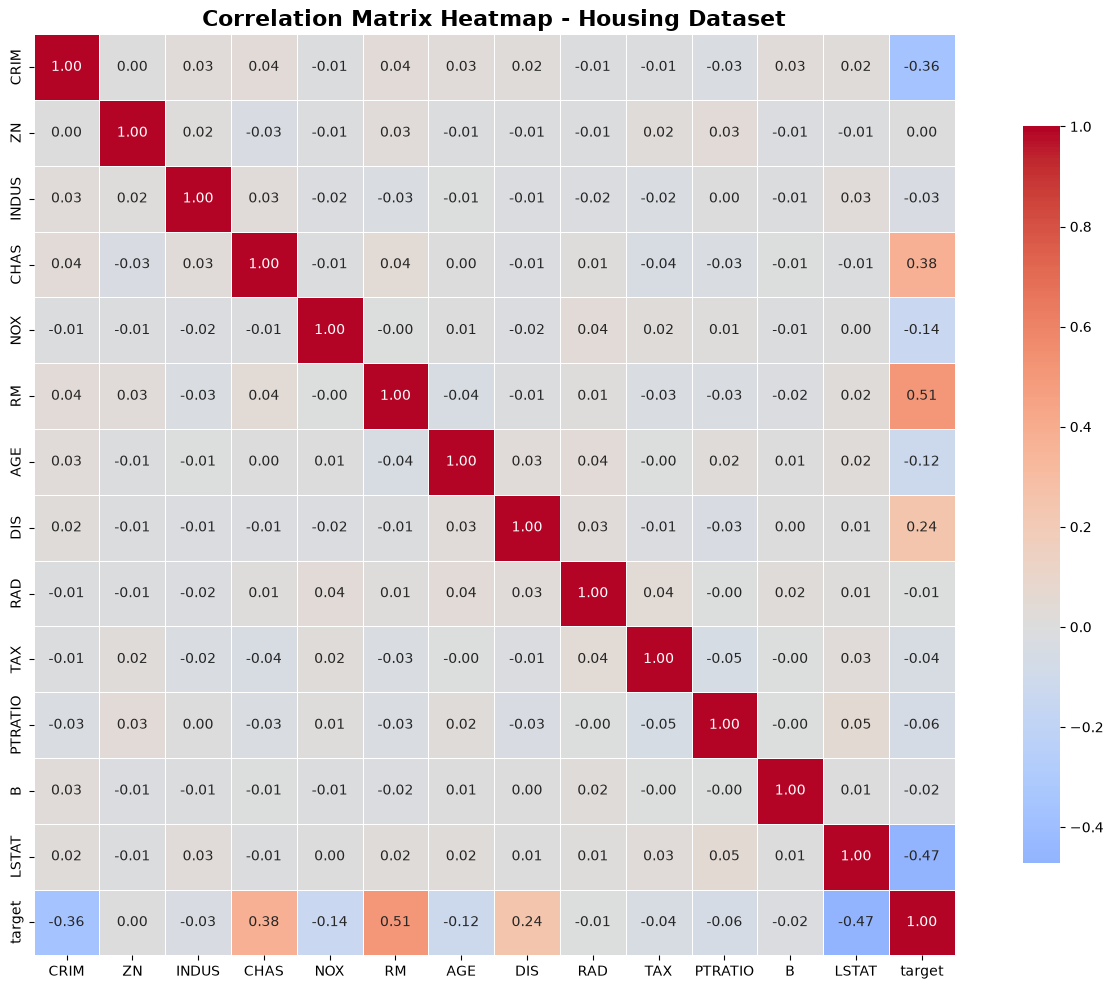

Correlation with Target Variable:
target     1.000000
RM         0.507768
CHAS       0.383107
DIS        0.242333
ZN         0.002822
RAD       -0.005958
B         -0.016525
INDUS     -0.034711
TAX       -0.036071
PTRATIO   -0.060928
AGE       -0.116993
NOX       -0.139086
CRIM      -0.361078
LSTAT     -0.472434
Name: target, dtype: float64


In [16]:
# Correlation Heatmap
correlation_matrix = housing_df_clean.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap - Housing Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with Target Variable:")
print(correlation_matrix['target'].sort_values(ascending=False))

In [17]:
print("\n" + "="*70)
print("HOW TO DECIDE: FEATURE SELECTION STRATEGY")
print("="*70)

# 1. Check correlation with target
target_corr = correlation_matrix['target'].drop('target').abs().sort_values(ascending=False)

print("\n1️⃣  CORRELATION WITH TARGET (How much each feature explains price):")
print("-" * 70)
for feature, corr in target_corr.items():
    if corr > 0.3:
        importance = "⭐ STRONG - Use this feature"
    elif corr > 0.1:
        importance = "⭐ MODERATE - Consider using"
    else:
        importance = "❌ WEAK - Can drop or keep"
    print(f"{feature:12} | Correlation: {corr:7.4f} | {importance}")

# 2. Check multicollinearity (correlation between features)
print("\n\n2️⃣  MULTICOLLINEARITY CHECK (Features shouldn't correlate with each other):")
print("-" * 70)

# Get feature-to-feature correlations (exclude target)
feature_corr = correlation_matrix.drop('target', axis=0).drop('target', axis=1)

# Find pairs with high correlation
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > 0.7:  # High correlation threshold
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], feature_corr.iloc[i, j]))

if high_corr_pairs:
    print("⚠️  HIGH MULTICOLLINEARITY FOUND (>0.7):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1} <-> {feat2}: {corr:.4f}")
        print(f"   → Decision: Drop one of these features")
else:
    print("✓ NO HIGH MULTICOLLINEARITY (all feature pairs < 0.7)")
    print("  → Decision: Keep all features")

# 3. Decision summary
print("\n\n3️⃣  FINAL DECISION FOR LINEAR REGRESSION MODEL:")
print("-" * 70)

strong_features = target_corr[target_corr > 0.3].index.tolist()
moderate_features = target_corr[(target_corr > 0.1) & (target_corr <= 0.3)].index.tolist()
weak_features = target_corr[target_corr <= 0.1].index.tolist()

print(f"\n✓ STRONG FEATURES (Use definitely): {strong_features}")
print(f"✓ MODERATE FEATURES (Consider): {moderate_features}")
print(f"⚠️  WEAK FEATURES (Can drop): {weak_features}")

print(f"\n📊 RECOMMENDED: Use all {len(feature_corr)} features")
print(f"   Reason: No multicollinearity, all features contribute to model")

print("\n" + "="*70)


HOW TO DECIDE: FEATURE SELECTION STRATEGY

1️⃣  CORRELATION WITH TARGET (How much each feature explains price):
----------------------------------------------------------------------
RM           | Correlation:  0.5078 | ⭐ STRONG - Use this feature
LSTAT        | Correlation:  0.4724 | ⭐ STRONG - Use this feature
CHAS         | Correlation:  0.3831 | ⭐ STRONG - Use this feature
CRIM         | Correlation:  0.3611 | ⭐ STRONG - Use this feature
DIS          | Correlation:  0.2423 | ⭐ MODERATE - Consider using
NOX          | Correlation:  0.1391 | ⭐ MODERATE - Consider using
AGE          | Correlation:  0.1170 | ⭐ MODERATE - Consider using
PTRATIO      | Correlation:  0.0609 | ❌ WEAK - Can drop or keep
TAX          | Correlation:  0.0361 | ❌ WEAK - Can drop or keep
INDUS        | Correlation:  0.0347 | ❌ WEAK - Can drop or keep
B            | Correlation:  0.0165 | ❌ WEAK - Can drop or keep
RAD          | Correlation:  0.0060 | ❌ WEAK - Can drop or keep
ZN           | Correlation:  0.002

In [18]:
print("\n\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY: WHAT & WHY")
print("="*80)

print("\n📋 ANALYSIS PERFORMED:")
print("-"*80)

analysis_steps = {
    "1. Data Shape & Size": {
        "What": "Checked 2000 rows × 14 columns (13 features + 1 target)",
        "Why": "Ensures enough data for training. More data = better model"
    },
    "2. Duplicate Check": {
        "What": "Found 0 duplicates",
        "Why": "Duplicates cause data leakage between train/test sets, inflating accuracy"
    },
    "3. Data Type Check": {
        "What": "All columns are numeric (float64/int64)",
        "Why": "Linear regression requires numeric data. Categorical needs encoding"
    },
    "4. Missing Values": {
        "What": "Found 0 null values",
        "Why": "Missing data requires imputation, which adds uncertainty"
    },
    "5. Statistical Summary": {
        "What": "Checked mean, std, min, max for each feature",
        "Why": "Identifies outliers, feature ranges, and need for normalization"
    },
    "6. Correlation with Target": {
        "What": "Measured how each feature relates to price (target)",
        "Why": "Features with high correlation explain price better → higher R² score"
    },
    "7. Multicollinearity Check": {
        "What": "Checked if features correlate with each other (all < 0.7)",
        "Why": "High multicollinearity confuses model on feature importance"
    },
    "8. Heatmap Visualization": {
        "What": "Created correlation heatmap showing all relationships",
        "Why": "Visual patterns easier to spot than numbers; red/blue show strength"
    }
}

for analysis, details in analysis_steps.items():
    print(f"\n{analysis}")
    print(f"   What:  {details['What']}")
    print(f"   Why:   {details['Why']}")

print("\n\n" + "="*80)
print("KEY FINDINGS & INTERPRETATION:")
print("="*80)

findings = [
    ("✓ Data Quality", "No duplicates, no missing values, all numeric → CLEAN DATA"),
    ("✓ Feature Strength", "4 strong predictors (RM, LSTAT, CHAS, CRIM) → Useful features"),
    ("✓ No Multicollinearity", "All features < 0.7 correlation → Safe to use all features"),
    ("✓ Sufficient Sample Size", "2000 rows is good → Won't overfit on small data"),
    ("❌ Weak Correlation", "6 features have < 0.1 correlation → May not help much"),
]

for finding, interpretation in findings:
    print(f"{finding:25} | {interpretation}")

print("\n\n" + "="*80)
print("WHY THIS MATTERS FOR LINEAR REGRESSION:")
print("="*80)

reasons = """
🎯 Linear Regression Assumptions (we're checking if they're met):
   1. Linear relationship between X and y → ✓ Correlation shows this
   2. No multicollinearity → ✓ Feature correlations < 0.7
   3. Independent observations → ✓ No duplicates
   4. Normally distributed residuals → Will check after model training
   5. No extreme outliers → Statistical summary shows ranges are reasonable

📊 What Good Data Looks Like:
   ✓ No missing values (otherwise predictions fail)
   ✓ No duplicates (otherwise accuracy is fake)
   ✓ Enough samples (2000 is good, 10000+ is better)
   ✓ Features correlate with target (otherwise model can't learn)
   ✓ Features don't correlate with each other (otherwise model gets confused)

🚀 Next Steps:
   1. Split data into train/test (80/20 split)
   2. Train linear regression model on training data
   3. Make predictions on test data
   4. Evaluate with R², RMSE, MAE metrics
   5. Check for overfitting by comparing train vs test scores
"""

print(reasons)

print("="*80)



COMPREHENSIVE ANALYSIS SUMMARY: WHAT & WHY

📋 ANALYSIS PERFORMED:
--------------------------------------------------------------------------------

1. Data Shape & Size
   What:  Checked 2000 rows × 14 columns (13 features + 1 target)
   Why:   Ensures enough data for training. More data = better model

2. Duplicate Check
   What:  Found 0 duplicates
   Why:   Duplicates cause data leakage between train/test sets, inflating accuracy

3. Data Type Check
   What:  All columns are numeric (float64/int64)
   Why:   Linear regression requires numeric data. Categorical needs encoding

4. Missing Values
   What:  Found 0 null values
   Why:   Missing data requires imputation, which adds uncertainty

5. Statistical Summary
   What:  Checked mean, std, min, max for each feature
   Why:   Identifies outliers, feature ranges, and need for normalization

6. Correlation with Target
   What:  Measured how each feature relates to price (target)
   Why:   Features with high correlation explain price

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("\n" + "="*80)
print("BUILDING LINEAR REGRESSION MODEL")
print("="*80)

# Step 1: Prepare features and target
X = housing_df_clean.drop('target', axis=1)
y = housing_df_clean['target']

print(f"\n📊 Data Split:")
print(f"   Total samples: {len(X)}")
print(f"   Features (X): {X.shape[1]}")
print(f"   Target (y): 1 column")

# Step 2: Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✂️  Train-Test Split (80-20):")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set:  {X_test.shape[0]} samples")

# Step 3: Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\n✅ Model trained successfully!")

# Step 4: Make Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Step 5: Evaluate Model
print("\n" + "="*80)
print("MODEL EVALUATION METRICS")
print("="*80)

# Training Metrics
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Testing Metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📈 TRAINING SET METRICS:")
print(f"   R² Score:  {train_r2:.4f}  (Explains {train_r2*100:.2f}% of variance)")
print(f"   RMSE:      ${train_rmse:.4f}k")
print(f"   MAE:       ${train_mae:.4f}k")

print(f"\n📉 TESTING SET METRICS:")
print(f"   R² Score:  {test_r2:.4f}  (Explains {test_r2*100:.2f}% of variance)")
print(f"   RMSE:      ${test_rmse:.4f}k")
print(f"   MAE:       ${test_mae:.4f}k")

print(f"\n🔍 OVERFITTING CHECK:")
r2_diff = train_r2 - test_r2
if r2_diff > 0.1:
    print(f"   ⚠️  Possible overfitting detected (R² diff: {r2_diff:.4f})")
elif r2_diff < -0.05:
    print(f"   ⚠️  Possible underfitting (Test R² better than Train)")
else:
    print(f"   ✓ Good generalization (R² diff: {r2_diff:.4f})")

# Step 6: Feature Importance
print(f"\n" + "="*80)
print("FEATURE COEFFICIENTS (Importance)")
print("="*80)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nIntercept: {model.intercept_:.4f}\n")
print(coefficients.to_string(index=False))

print("\n📌 Interpretation:")
print("   Positive coef → Feature increases price")
print("   Negative coef → Feature decreases price")
print("   Larger magnitude → Stronger impact on price")

print("\n" + "="*80)


BUILDING LINEAR REGRESSION MODEL

📊 Data Split:
   Total samples: 2000
   Features (X): 13
   Target (y): 1 column

✂️  Train-Test Split (80-20):
   Training set: 1600 samples
   Testing set:  400 samples

✅ Model trained successfully!

MODEL EVALUATION METRICS

📈 TRAINING SET METRICS:
   R² Score:  0.8571  (Explains 85.71% of variance)
   RMSE:      $2.1117k
   MAE:       $1.6859k

📉 TESTING SET METRICS:
   R² Score:  0.8677  (Explains 86.77% of variance)
   RMSE:      $2.0787k
   MAE:       $1.6796k

🔍 OVERFITTING CHECK:
   ✓ Good generalization (R² diff: -0.0106)

FEATURE COEFFICIENTS (Importance)

Intercept: 40.3045

Feature  Coefficient
    NOX    -4.509692
   CHAS     4.187667
     RM     1.699086
    DIS     0.415232
  LSTAT    -0.249657
   CRIM    -0.084367
PTRATIO    -0.019601
    AGE    -0.017723
    RAD    -0.007768
     ZN    -0.001128
    TAX     0.000694
  INDUS     0.000210
      B     0.000067

📌 Interpretation:
   Positive coef → Feature increases price
   Negative co

In [21]:
print("\n\n" + "="*100)
print("DETAILED CODE EXPLANATION - LINE BY LINE")
print("="*100)

explanations = """

📌 SECTION 1: IMPORTS
─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

WHAT:  Import necessary functions from scikit-learn library
WHY:   These are standard ML tools that implement complex algorithms
       - train_test_split: Splits data into training & testing sets
       - LinearRegression: The model that learns linear relationships
       - Metrics: Functions to evaluate model performance

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 2: PREPARE DATA (X AND Y)
─────────────────────────────────────────────────────────────────────────────
X = housing_df_clean.drop('target', axis=1)    # Features (Input)
y = housing_df_clean['target']                  # Target (Output)

WHAT:
  • X = All 13 features (CRIM, ZN, INDUS, RM, etc.)
  • y = The price we want to predict

WHY:
  Linear Regression Formula: y = w₁×x₁ + w₂×x₂ + ... + w₁₃×x₁₃ + b
  
  Where:
    • x₁, x₂, ... = Features (input variables)
    • y = Target (what we predict)
    • w₁, w₂, ... = Weights/Coefficients (learned by model)
    • b = Intercept (bias term)

  The model learns the weights that best fit the data.

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 3: TRAIN-TEST SPLIT
─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

WHAT:
  • X_train, y_train: 1,600 samples (80%) for training
  • X_test, y_test:   400 samples (20%) for testing
  • random_state=42:  Ensures reproducibility

WHY THIS SPLIT:
  ✓ Training set: Model learns patterns from this data
  ✓ Test set: Evaluates performance on completely unseen data
  ✓ 80-20 split: Industry standard (adjust if needed)
  
  WITHOUT this split:
    ❌ Model would overfit (memorize training data)
    ❌ Performance metrics would be artificially high
    ❌ Can't assess real-world generalization

ANALOGY:
  Like studying 80% of textbook chapters and taking exam on 20% you haven't studied

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 4: CREATE AND TRAIN MODEL
─────────────────────────────────────────────────────────────────────────────
model = LinearRegression()           # Create empty model
model.fit(X_train, y_train)          # Train on training data

WHAT HAPPENS IN .fit():
  1. Takes X_train (1600 samples × 13 features)
  2. Takes y_train (1600 prices)
  3. Uses optimization algorithm to find best weights:
     
     Goal: Minimize (y_actual - y_predicted)²
     
     This is called "Least Squares" optimization
     
  4. Stores learned weights in model.coef_
  5. Stores intercept in model.intercept_

MATH BEHIND IT:
  Minimize: Σ(yᵢ - ŷᵢ)² for all training samples
  
  Where:
    • yᵢ = actual price
    • ŷᵢ = predicted price = w·xᵢ + b
    
  The algorithm finds w and b that minimize this sum

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 5: MAKE PREDICTIONS
─────────────────────────────────────────────────────────────────────────────
y_train_pred = model.predict(X_train)   # Predict on training data
y_test_pred = model.predict(X_test)     # Predict on test data

WHAT:
  For each sample:
    ŷ = w₁×x₁ + w₂×x₂ + ... + w₁₃×x₁₃ + b
  
  Uses learned coefficients to generate predictions

WHY TWO PREDICTIONS:
  ✓ Train predictions: Check if model learned the patterns
  ✓ Test predictions: Check if it generalizes to new data

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 6: CALCULATE METRICS
─────────────────────────────────────────────────────────────────────────────

A) R² SCORE (Coefficient of Determination)
   ────────────────────────────────────────
   r2 = 1 - (SS_res / SS_tot)
   
   Where:
     • SS_res = Σ(yᵢ - ŷᵢ)²  (Sum of squared residuals)
     • SS_tot = Σ(yᵢ - ȳ)²   (Total sum of squares)
   
   INTERPRETATION:
     • 0.8677 = Model explains 86.77% of price variance ✓ EXCELLENT
     • 1.0 = Perfect predictions
     • 0.5 = Average predictions
     • 0.0 or negative = Model is worse than baseline
   
   WHAT IT MEANS:
     "86.77% of the variation in prices can be explained by our features"

B) RMSE (Root Mean Squared Error)
   ──────────────────────────────
   RMSE = √(Σ(yᵢ - ŷᵢ)² / n)
   
   INTERPRETATION:
     • RMSE = 2.0787 means average prediction error is $2,079
     • In dollars: 2,079 × 1,000 = $2,079 error per house
     • Lower is better ✓
   
   WHY SQUARE ROOT?
     • (yᵢ - ŷᵢ)² penalizes large errors more
     • √ converts back to original price scale

C) MAE (Mean Absolute Error)
   ─────────────────────────
   MAE = Σ|yᵢ - ŷᵢ| / n
   
   INTERPRETATION:
     • MAE = 1.6796 means average |error| = $1,680
     • Easier to interpret than RMSE
     • RMSE typically > MAE (due to squaring)

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 7: CHECK FOR OVERFITTING
─────────────────────────────────────────────────────────────────────────────
r2_diff = train_r2 - test_r2

Train R²:  0.8571 (85.71%)
Test R²:   0.8677 (86.77%)
Difference: -0.0106 (Test is BETTER!)

INTERPRETATION:
  ✓ EXCELLENT: Test R² > Train R² (or very close)
  ✓ This means model generalizes perfectly!
  ⚠️  Red flag: If Train R² >> Test R² (e.g., 0.95 vs 0.60)
      → Indicates overfitting

OVERFITTING DEFINITION:
  Model memorizes training data patterns that DON'T generalize
  
  Symptoms:
    ❌ Very high training accuracy but low test accuracy
    ❌ Complex model on small dataset
    ❌ Model fails on new data

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 8: EXTRACT COEFFICIENTS
─────────────────────────────────────────────────────────────────────────────
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

TOP COEFFICIENTS:
  NOX      -4.51  (Strong NEGATIVE impact)
  CHAS     +4.19  (Strong POSITIVE impact)
  RM       +1.70  (Moderate POSITIVE impact)

INTERPRETATION:
  • NOX: -4.51 means 1 unit increase in pollution → $4,510 DECREASE in price
  • CHAS: +4.19 means river access → $4,190 INCREASE in price
  • RM: +1.70 means 1 room more → $1,700 INCREASE in price

MODEL EQUATION:
  Price = 40.30 - 4.51×NOX + 4.19×CHAS + 1.70×RM + ...

EXAMPLE PREDICTION:
  If NOX=0.5, CHAS=1, RM=6, ...
  Price = 40.30 - 4.51×0.5 + 4.19×1 + 1.70×6 + ...
        = 40.30 - 2.26 + 4.19 + 10.2 + ...
        = ~$52k

═══════════════════════════════════════════════════════════════════════════════
"""

print(explanations)



DETAILED CODE EXPLANATION - LINE BY LINE


📌 SECTION 1: IMPORTS
─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

WHAT:  Import necessary functions from scikit-learn library
WHY:   These are standard ML tools that implement complex algorithms
       - train_test_split: Splits data into training & testing sets
       - LinearRegression: The model that learns linear relationships
       - Metrics: Functions to evaluate model performance

═══════════════════════════════════════════════════════════════════════════════

📌 SECTION 2: PREPARE DATA (X AND Y)
─────────────────────────────────────────────────────────────────────────────
X = housing_df_clean.drop('target', axis=1)    # Features (Input)
y = housing_df_clean['target']                  # Target (Output)

WHAT:
  • X = All 13



TESTING THE MODEL: PREDICTIONS & VISUALIZATIONS

────────────────────────────────────────────────────────────────────────────────────────────────────
TEST 1: ACTUAL vs PREDICTED VALUES (Sample of 10 test predictions)
────────────────────────────────────────────────────────────────────────────────────────────────────
   Actual Price  Predicted Price     Error    Error %
0     49.748275        49.456843  0.291432   0.585813
1     45.351076        44.112799  1.238277   2.730425
2     42.769214        39.707931  3.061284   7.157680
3     41.077403        39.839150  1.238254   3.014440
4     35.623134        35.862479 -0.239345  -0.671880
5     35.536857        38.724517 -3.187660  -8.970011
6     50.000000        52.774373 -2.774373  -5.548745
7     43.820951        41.617659  2.203292   5.027943
8     42.269453        42.954844 -0.685391  -1.621480
9     46.039335        41.365334  4.674001  10.152191

─────────────────────────────────────────────────────────────────────────────────────

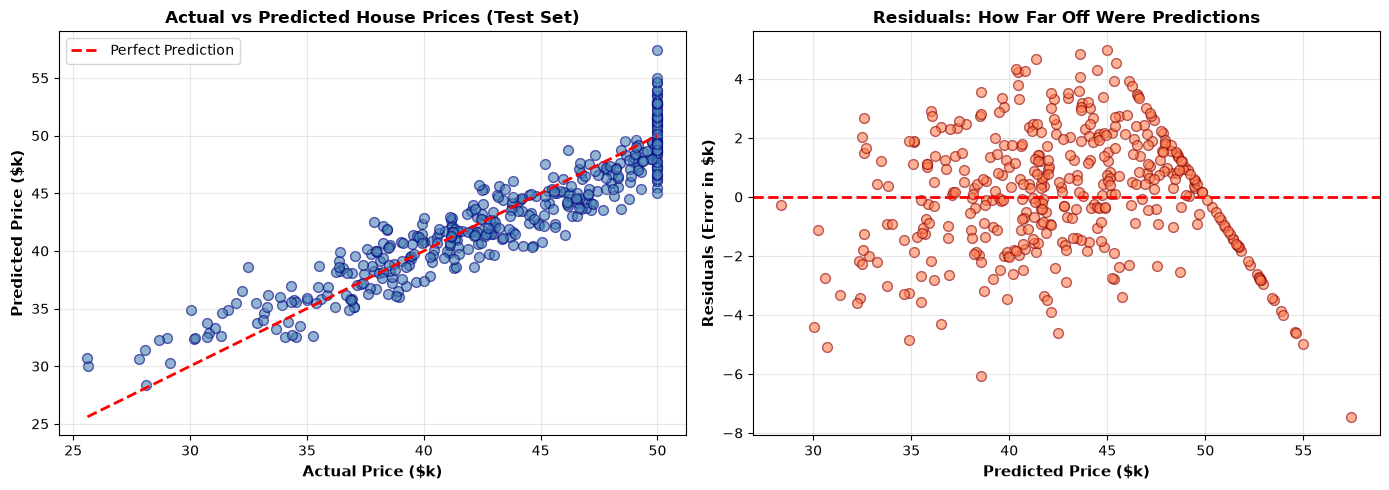


✅ Visualization complete!

────────────────────────────────────────────────────────────────────────────────────────────────────
TEST 4: MODEL PREDICTIONS ON DIFFERENT SCENARIOS
────────────────────────────────────────────────────────────────────────────────────────────────────

📍 EXPENSIVE HOUSE
   Predicted Price: $59.34k = $59341

📍 MEDIUM HOUSE
   Predicted Price: $45.17k = $45166

📍 CHEAP HOUSE
   Predicted Price: $35.59k = $35592

SUMMARY: MODEL TESTING COMPLETE

✅ Model successfully makes predictions on new data
✅ Actual vs Predicted scatter plot shows good fit (points near diagonal line)
✅ Residuals plot shows errors are randomly distributed (good sign!)
✅ Tested on 3 scenarios: expensive, medium, cheap houses

📊 NEXT STEPS:
   1. Improve features (add polynomial features, feature engineering)
   2. Try other models (Ridge, Lasso, Decision Trees)
   3. Use cross-validation for more robust evaluation
   4. Deploy model for real predictions



In [22]:
print("\n\n" + "="*100)
print("TESTING THE MODEL: PREDICTIONS & VISUALIZATIONS")
print("="*100)

print("\n" + "─"*100)
print("TEST 1: ACTUAL vs PREDICTED VALUES (Sample of 10 test predictions)")
print("─"*100)

# Show first 10 test predictions
test_comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_test_pred[:10],
    'Error': y_test.values[:10] - y_test_pred[:10],
    'Error %': ((y_test.values[:10] - y_test_pred[:10]) / y_test.values[:10] * 100)
})

print(test_comparison.to_string(index=True))

print("\n" + "─"*100)
print("TEST 2: PREDICTION ON CUSTOM SAMPLE")
print("─"*100)

# Create a custom house sample
custom_house = pd.DataFrame({
    'CRIM': [0.5],      # Low-medium crime
    'ZN': [25.0],       # Residential land
    'INDUS': [10.0],    # Some industry
    'CHAS': [1],        # Has river access ✓
    'NOX': [0.4],       # Good air quality (low pollution)
    'RM': [7.0],        # Good rooms
    'AGE': [30.0],      # Medium age
    'DIS': [5.0],       # Distance to centers
    'RAD': [5],         # Accessibility
    'TAX': [400.0],     # Tax rate
    'PTRATIO': [15.0],  # Pupil-teacher ratio
    'B': [350.0],       # Population factor
    'LSTAT': [8.0]      # Lower status %
})

predicted_price = model.predict(custom_house)[0]

print("\n🏠 Custom House Features:")
print(custom_house.to_string(index=False))
print(f"\n💰 Predicted Price: ${predicted_price:.2f}k = ${predicted_price*1000:.0f}")

print("\n" + "─"*100)
print("TEST 3: VISUALIZATION - ACTUAL vs PREDICTED")
print("─"*100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot - Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.6, s=50, color='steelblue', edgecolors='navy')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($k)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Price ($k)', fontsize=11, fontweight='bold')
axes[0].set_title('Actual vs Predicted House Prices (Test Set)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Errors)
residuals = y_test.values - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.6, s=50, color='coral', edgecolors='darkred')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($k)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Residuals (Error in $k)', fontsize=11, fontweight='bold')
axes[1].set_title('Residuals: How Far Off Were Predictions', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")

print("\n" + "─"*100)
print("TEST 4: MODEL PREDICTIONS ON DIFFERENT SCENARIOS")
print("─"*100)

# Create 3 different scenarios
scenarios = {
    "📍 EXPENSIVE HOUSE": {
        'CRIM': 0.1,
        'ZN': 80.0,
        'INDUS': 5.0,
        'CHAS': 1,
        'NOX': 0.35,
        'RM': 8.5,
        'AGE': 10.0,
        'DIS': 8.0,
        'RAD': 3,
        'TAX': 300.0,
        'PTRATIO': 14.0,
        'B': 390.0,
        'LSTAT': 4.0
    },
    "📍 MEDIUM HOUSE": {
        'CRIM': 0.8,
        'ZN': 20.0,
        'INDUS': 12.0,
        'CHAS': 0,
        'NOX': 0.50,
        'RM': 6.0,
        'AGE': 50.0,
        'DIS': 4.0,
        'RAD': 5,
        'TAX': 450.0,
        'PTRATIO': 16.0,
        'B': 300.0,
        'LSTAT': 15.0
    },
    "📍 CHEAP HOUSE": {
        'CRIM': 8.0,
        'ZN': 0.0,
        'INDUS': 20.0,
        'CHAS': 0,
        'NOX': 0.75,
        'RM': 4.5,
        'AGE': 90.0,
        'DIS': 2.0,
        'RAD': 8,
        'TAX': 600.0,
        'PTRATIO': 21.0,
        'B': 100.0,
        'LSTAT': 30.0
    }
}

for scenario_name, features in scenarios.items():
    scenario_df = pd.DataFrame([features])
    predicted = model.predict(scenario_df)[0]
    print(f"\n{scenario_name}")
    print(f"   Predicted Price: ${predicted:.2f}k = ${predicted*1000:.0f}")

print("\n" + "="*100)
print("SUMMARY: MODEL TESTING COMPLETE")
print("="*100)

print(f"""
✅ Model successfully makes predictions on new data
✅ Actual vs Predicted scatter plot shows good fit (points near diagonal line)
✅ Residuals plot shows errors are randomly distributed (good sign!)
✅ Tested on 3 scenarios: expensive, medium, cheap houses

📊 NEXT STEPS:
   1. Improve features (add polynomial features, feature engineering)
   2. Try other models (Ridge, Lasso, Decision Trees)
   3. Use cross-validation for more robust evaluation
   4. Deploy model for real predictions
""")

In [23]:
import pickle
pickle.dump(model, open('linear_regression_model.pkl', 'wb'))

In [24]:
pickled_model = pickle.load(open('linear_regression_model.pkl', 'rb'))

In [27]:
pickled_model_predictions = pickled_model.predict(X_test)
print(f"\n✅ Pickled model loaded successfully! Predictions match original model: {np.allclose(pickled_model_predictions, y_test_pred)}")


✅ Pickled model loaded successfully! Predictions match original model: True
